# Travel Reimbursement Approval Agent

## Gen AI + Agentic AI Assignment

This notebook implements an AI-assigned Travel Reimbursement Agent.

### Objective

The agent evaluates employee travel reimbursement claims against the provided travel policy and produces a structured recommendation.

# Setup

### Requirements 

1) Python 3.10+
2) Jupyter Notebook
3) VS Code
4) Groq API Key ( Just paste the Groq API key in .env file.)

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel

In [3]:
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)

## Storing the Policy and Claim Samples

We will keep the provided policies and claims in a Python dictionary.

In [4]:
POLICY = {
        "eligible_categories": [
            "airfare",
            "lodging",
            "meals",
            "ground_transport",
            "conference_fees"
        ],
            "Ineligible_categories": [
                "alcohol",
                "minibar",
                "spa",
                "gym",
                "personal_entertainment",
                "personal_shoping",
                "gifts",
                "traffic_fines",
                "penalties"
                "late_fees",
                "personal_expenses"
            ],
    "Limits": {
        "meals": {
        "limit": 75,
        "unit" : "day",
        "policy_ref": "POL-PD-01"
    },
    "lodging": {
            "limit": 200,
            "unit" : "night",
            "policy_ref": "POL-PD-02"
        },
    "ground transport": {
            "limit": 50,
            "unit" : "day",
            "policy_ref": "POL-PD-03"
    }
        },    
    "receipt_policy": {
            "amount_threshold": 25,
            "policy_ref_required": "POL-RCT-01",
            "policy_ref_missing": "POL-RCT-02"
    },
    "approval": {
            "auto_approval_limit":500,
            "manager_limit": 2000,
            "policy_ref": "POL-APR-03"
    }
}

In [5]:
Claims = [
    {
        "claim_id" : "CLM-001",
        "employee":"A. Rivera",
        "trip_start": "2026-06-10",
        "trip_end": "2026-06-20",
        "submitted": "2026-06-20",
        "items": [
            {
                "category": "airfare",
                "description": "Round-trip economy airfare",
                "amount": 420,
                "units": 1,
                "receipt_attached":True
            },
            {
                "category": "lodging",
                "description": "Hotel, 2 nights @ $180",
                "amount": 360,
                "units":2,
                "receipt_attached":True
                        },
            {
                "category": "meals",
                "description": "Meals, 3 days @ $60/day",
                "amount": 180,
                "units":3,
                "receipt_attached":True
                                    }, 
            {
                "category": "conference_fees",
                "description": "conference registration",
                "amount": 150,
                "units":1,
                "receipt_attached":True
            },                                   
        ]
    },
    {
            "claim_id" : "CLM-002",
            "employee":"B. Osei",
            "trip_Start": "2026-06-14",
            "trip_end": "2026-06-15",
            "submitted": "2026-06-25",
            "items": [
                {
                    "category": "spa",
                    "description": "Hotel spa package",
                    "amount": 300,
                    "units":1,
                    "receipt_attached":True
                },
                {
                    "category": "minibar",
                    "description": "In-room minibar",
                    "amount": 80,
                    "units":1,
                    "receipt_attached":True
                            },
                                           
            ]
        },
    {
            "claim_id" : "CLM-003",
            "employee":"C. Nakamura",
            "trip_Start": "2026-06-8",
            "trip_end": "2026-06-10",
            "submitted": "2026-06-22",
            "items": [
                {
                    "category": "airfare",
                    "description": "Round-trip economy airfare",
                    "amount": 300,
                    "units":1,
                    "receipt_attached":True
                },
                {
                    "category": "lodging",
                    "description": "Hotel, 2 nights @ $250",
                    "amount": 500,
                    "units":2,
                    "receipt_attached":True
                            },
                {
                    "category": "meals",
                    "description": "Meals, 2 days @ $70/day",
                    "amount": 140,
                    "units":2,
                    "receipt_attached":True
                                        }, 
                                                 
            ]
        }, 
    {
            "claim_id" : "CLM-004",
            "employee":"D. Fischer",
            "trip_Start": "2026-06-16",
            "trip_end": "2026-06-18",
            "submitted": "2026-06-28",
            "items": [
                {
                    "category": "airfare",
                    "description": "Business-class international airfare",
                    "amount": 2400,
                    "units":1,
                    "receipt_attached":True
                },
                {
                    "category": "lodging",
                    "description": "Hotel, 3 nights",
                    "amount": 600,
                    "units":3,
                    "receipt_attached":False
                            },                                  
            ]
        },
    {
            "claim_id" : "CLM-005",
            "employee":"E. Haddad",
            "trip_Start": "2026-06-11",
            "trip_end": "2026-06-11",
            "submitted": "2026-06-24",
            "items": [
                {
                    "category": "meals",
                    "description": "Client dinner for 4 (busines development)",
                    "amount": 220,
                    "units":1,
                    "receipt_attached":False
                                        },                                    
            ]
        },           
]

### Tool 1 - Policy Checker

In [6]:
@tool
def policy_checker(category:str, amount: float, units:int, description:str):

    """
    Checks a reimbursement item against travel reimbursement policy.
    """
    category = category.lower()

    # Ineligible expenses

    if category in POLICY["Ineligible_categories"]:
        return {
            "eligible":False,
            "manual_review":False,
            "approved_amount":amount,
            "policy_ref":"POL-CAT-02",
            "reason":"Expense category is not eligible."
        }

    # Airfare

    if category == "airfare":
        description_lower = description.lower()

        if "business" in description_lower or "first" in description_lower:
            return {
                "eligible":True,
                "manual_review":True,
                "approved_amount":0,
                "deducted_amount":0,
                "policy_ref":"POL-AIR-01",
                "reason": "Business/first class airfare requires manual review."
            }
        return {
                "eligible":True,
                "manual_review":False,
                "approved_amount":amount,
                "deducted_amount":0,
                "policy_ref":"POL-AIR-01",
                "reason": "Economy sirfare is eligible."            
        }

    # Limited categories

    if category in POLICY["Limits"]:
        rule = POLICY["Limits"][category]
        maximum = rule["limit"] * units
        approved = min(amount, maximum)
        deducted = amount - approved

        return {
                "eligible":True,
                "manual_review":False,
                "approved_amount":approved,
                "deducted_amount":deducted,
                "policy_ref":rule["policy_ref"],
                "reason": f"Maximum allowed is ${rule['limit']} per {rule['unit']}."            
        }    

    # Conference

    if category == "conference_fees":
        return {
                "eligible":True,
                "manual_review":False,
                "approved_amount":amount,
                "deducted_amount":0,
                "policy_ref":"POL-CAT-01",
                "reason": "Conference expense is eligible."            
        }

    # unknown category

    return {
            "eligible":False,
            "manual_review":True,
            "approved_amount":0,
            "deducted_amount":0,
            "policy_ref":"POL-CAT-01",
            "reason": "Unknown category requires manual review."
    }




### Tool 2 - Receipt Checker

In [7]:
@tool
def receipt_checker(category:str, amount:float, receipt:bool):

    """
    Checks whether the required receipt is available.
    """

    category = category.lower()

    receipt_required = (
        amount>25 or category in ["airfare", "lodging"]
    )

    if receipt_required and not receipt:
        return {
            "receipt_required": True,
            "receipt_present":False,
            "manual_review":True,
            "policy_ref":"POL-RCT-02",
            "reason":"Required receipt is missing."
        }
    return {
            "receipt_required": receipt_required,
            "receipt_present":receipt,
            "manual_review":False,
            "policy_ref":"POL-RCT-01",
            "reason":"Receipt requirement satisfied."
    }

### Bind both tools to LLM

In [8]:
tools = [
    policy_checker,
    receipt_checker
]

llm_with_tools = llm.bind_tools(tools)

In [9]:
SYSTEM_PROMPT = """
You are a Travel Reimbursement Approval Agent.
Your job is to evaluate a travel reimbursement claim using the company travel policy.
The final answer must contain only the requested structured result.
Do not add explanations, markdown, code fences, or conversational text.

For every claim item:

1) Use policy_checker tool to check eligiblity and reimbursement limits.
2) Use receipt_checker tool to check receipt requirements.

Do not calculate policy limits yoyrself as policy_checker tool can provide the result.

After getting the tool results, summarize the findings.

Important rules:

1) Business or first-class airfare requires MANUAL_REVIEW.
2) Missing required receipt require MANUAL_REVIEW.
3) Expenses above meals/lodging/transport limits should be partially approved and the excess are deducted.
4) Completely ineligibe expenses should be rejected.
5) Claims above $2000 require MANUAL_REVIEW.
6) Claims submitted more than 30 days after the trip require MANUAL_REVIEW.

Return ONLY the requested structured fields.
Do not include markdown.
Do not include explanations outside the structured response.


Don't invent policy rules by yourself.
"""

In [10]:
from typing import TypedDict, Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
import json

class AgentState(TypedDict):
    claim : dict
    messages: Annotated[list,add_messages]
    final_result: dict

In [11]:
def agent_node(State:AgentState):
    if not State["messages"]:
        messages = [SystemMessage(content=SYSTEM_PROMPT),
                    HumanMessage(content=f"""Evaluate this reimbursement claim:{json.dumps(State["claim"], indent=2)}""")]

    else:
        messages = State["messages"]
        
    response = llm_with_tools.invoke(messages)

    if not State["messages"]:
        return {
            "messages" : [messages[0], messages[1], response]
        }
    return {"messages": [response]}

    

### Route between Agent and Tools

In [12]:
def route_agent(State:AgentState):
    last_message = State["messages"][-1]

    if getattr(last_message, "tool_calls", None):
        return "tools"
    return "decision"

In [13]:
from datetime import datetime

def calculate_decision(claim, messages):
    total_approved = 0
    total_deducted = 0
    manual_review = False
    missing_docs = []
    policy_refs = set()
    reasons = []
    tool_results = []

    for message in messages:
        if message.type == "tool":
            try:
                result = json.loads(message.content)
                tool_results.append(result)
            except:
                pass


    for result in tool_results:
        if "approved_amount" in result:
            total_approved += result["approved_amount"]
            total_deducted += result.get("deducted_amount", 0)

        if result.get("manual_review"):
            manual_review = True
            reasons.append(result["reason"])

        if result.get("policy_ref"):
            policy_refs.add(result["policy_ref"])

        if result.get("receipr_required") and not result.get("receipt_present"):
            missing_docs.append("Required receipt")


    trip_end = datetime.strptime(claim["trip_end"], "%Y-%m-%d")
    submitted = datetime.strptime(claim["submitted"], "%Y-%m-%d")

    days_to_submit = (submitted - trip_end).days

    if days_to_submit > 30:
        manual_review = True
        reasons.append("Claim was submitted more than 30 days after the trip.")
        policy_refs.add("POL-TIME-01")

    if total_approved > 2000:
        manual_review = True
        reasons.append("Claim exceed the $2000 approval authority.")
        policy_refs.add("POL-APR-03")

    if manual_review:
        decision = "MANUAL_REVIEW"

        final_approved = 0
        final_deducted = 0
    elif total_approved==0:
        decision = "REJECT"

        final_approved = 0
        final_deducted = total_deducted
    elif total_deducted>0:
        decision = "PARTIAL_APPROVE"

        final_approved = total_approved
        final_deducted = total_deducted 
    else: 
        decision = "APPROVE"

        final_approved = total_approved
        final_deducted =0

    return { 
        "decision":decision,
        "approved_amount":final_approved,
        "deducted_amount":final_deducted,
        "missing_docs":list(set(missing_docs)),
        "policy_refs":sorted(policy_refs),
        "reasons":reasons
    }               



    

### Structured Output

In [14]:
class FinalDecision(BaseModel):
    claim_id:str
    decision:Literal["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"]

    approved_amount:float
    deducted_amount : float
    missing_docs:list[str]
    policy_refs:list[str]
    confidence:float
    explanation : str
    tools_used:list[str]
    

### Decision Node

In [15]:
def decision_node(State:AgentState):
    evaluation = calculate_decision(State["claim"], State["messages"])
    decision = evaluation["decision"]

    if decision=="MANUAL_REVIEW":
        confidence = 0.85
    elif decision=="REJECT":
        confidence = 0-98
    elif decision=="PARTIAL_APPROVE":
        confidence=0.97
    else:
        confidence=0.99

    if evaluation["reasons"]:
        explanation = ";".join(evaluation["reasons"])
    else:
        if decision=="APPROVE":
            explanation=("All Claimed expenses are eligible, receipts are available and expenses are within policy limits.")

        elif decision=="PARTIAL_APPROVE":
            explanation=("The claim is partially approve because some expense are exceed the policy limits.")

        elif decision=="REJECT":
            explanation=("The claim contains only ineligible expenses.")

        else:
            explanation=("The claim requires manual review.")



    tools_used = []

    for message in State["messages"]:
        if hasattr(message, "tool_calls"):
            for call in message.tool_calls:
                if call["name"] not in tools_used:
                    tools_used.append(call["name"])

    result = FinalDecision(claim_id=State["claim"]["claim_id"],
                           decision=evaluation["decision"],
                           approved_amount=evaluation["approved_amount"],
                           deducted_amount=evaluation["deducted_amount"],
                           missing_docs=evaluation["missing_docs"],
                           policy_refs=evaluation["policy_refs"],
                           confidence=confidence,
                           explanation=explanation,
                           tools_used=tools_used)

    return {
        "messages" : [HumanMessage(content=result.model_dump_json())]
    }


### Now convert our Nodes into Graphs

In [16]:
graphs = StateGraph(AgentState)

graphs.add_node("agent", agent_node)
graphs.add_node("tools", ToolNode(tools))
graphs.add_node("decision", decision_node)

graphs.add_edge(START, "agent")
graphs.add_conditional_edges("agent", route_agent,{"tools":"tools", "decision":"decision"})
graphs.add_edge("tools", "agent")
graphs.add_edge("decision", END)

Final_graphs = graphs.compile()

## Final Graph or work flow 

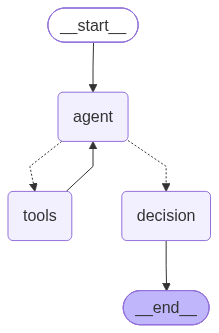

In [17]:
Final_graphs

In [18]:
result = Final_graphs.invoke({"claim":Claims[1], "messages":[]})
print(result["messages"][-1].content)


{"claim_id":"CLM-002","decision":"APPROVE","approved_amount":380.0,"deducted_amount":0.0,"missing_docs":[],"policy_refs":["POL-CAT-02","POL-RCT-01"],"confidence":0.99,"explanation":"All Claimed expenses are eligible, receipts are available and expenses are within policy limits.","tools_used":["policy_checker","receipt_checker"]}


In [19]:
final_results = []

for claim in Claims:
    result = Final_graphs.invoke({"claim":claim, "messages":[]})

    output = json.loads(result["messages"][-1].content)

    final_results.append(output)

In [20]:
print(
    json.dumps(
        final_results,
        indent=2
    )
)

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01"
    ],
    "confidence": 0.99,
    "explanation": "All Claimed expenses are eligible, receipts are available and expenses are within policy limits.",
    "tools_used": [
      "policy_checker",
      "receipt_checker"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "APPROVE",
    "approved_amount": 380.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02",
      "POL-RCT-01"
    ],
    "confidence": 0.99,
    "explanation": "All Claimed expenses are eligible, receipts are available and expenses are within policy limits.",
    "tools_used": [
      "policy_checker",
      "receipt_checker"
    ]
  },
  {
    "claim_id": "CLM-003",
    "decision": "PARTIAL_APPROVE",
    "approved_a

## Design Notes & Reasoning

### Architecture

This solution uses a LangGraph agent.

The workflow is:   
Claim,  
LLM Agent,   
Policy checker / Receipt checker,   
Decision logic,   
Output

### Role of LLM

Understanding the claim,   
Deciding when tools are required,   
calling the appropriate tool,   

### Role of Pyhton

Reimbursement calculation,   
Approval threshold,   
Final decision selection,   

### Manual Review

System route a claim to Manual Review:    

When Business/first class airfare is detected,   
When required receipt is missing,   
When claim exceed limit $2000,   
 
### Future Improvement

Human approval interrupt,    
RAG for large policy documents